# CLASIFICACIÓN DE TIPOS DE TUMORES MALIGNOS DE CÁNCER DE MAMA MEDIANTE TÉCNICAS DE TRANSFER LEARNING Y EXPLICABILIDAD

## Trabajo Fin de Grado
### Hecho por: Felipe Sebastián Galarza

En este notebook se desarrolla un sistema de **clasificación automática de imágenes histológicas de cáncer de mama** para distinguir entre los cuatro subtipos malignos del dataset **BreaKHis**.  
Además del entrenamiento y evaluación de **InceptionV3**, también se analiza en qué regiones de la imagen se apoya el modelo para tomar sus decisiones mediante **GradCAM++**.

## Ingeniería del dato

Antes de entrenar el modelo, es necesario preparar correctamente el conjunto de datos. En esta sección se trabaja sobre la organización de las imágenes, la revisión de su estructura y calidad, la división en entrenamiento, validación y test, y la aplicación de las transformaciones necesarias para que puedan utilizarse de forma adecuada en la arquitectura.

El objetivo de esta fase es asegurar que los datos estén bien estructurados, sean coherentes y puedan alimentar al modelo de forma fiable durante todo el proceso de entrenamiento y evaluación.

### Instalación librerias

En esta sección, en caso de que la persona que quiera ejecutar el notebook no tenga todas las librerias instaladas, se realiza el comando de pip install para hacer la instalación.

In [ ]:
! pip install split-folders tensorflow tensorboard matplotlib scikit-learn seaborn Pillow google

### Importación de librerías

Antes de comenzar con el código de los modelos y del análisis descriptivo de las imagenes, es fundamental importar las librerias o paquetes fundamentales, los cuales han sido instalados previamente en el apartado anterior.

In [ ]:
# Se importan las librerias
from google.colab import files
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from keras import Input, Model
from itertools import product
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import numpy as np
import tensorflow as tf
import os
import zipfile
import matplotlib.pyplot as plt
import random
import signal
import splitfolders
import glob
import shutil
import pandas as pd
from tensorflow.keras.applications import (
    DenseNet121, DenseNet201,
    ResNet50, ResNet101V2, ResNet152V2,
    EfficientNetB0, EfficientNetB4,
    InceptionV3, InceptionResNetV2,
    VGG16, Xception
)
from sklearn.utils import class_weight
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
from tensorflow.keras.preprocessing.image import img_to_array, load_img, array_to_img
from sklearn.model_selection import train_test_split
from PIL import Image
import tarfile
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
import gc
import matplotlib.cm as mpl_cm
from tensorflow.keras.models import Model
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import warnings
import logging


En este bloque se reducen los mensajes de advertencia generados por **Python**, **TensorFlow** y librerías internas como **absl**. El objetivo no es ocultar errores importantes, sino limpiar la salida del notebook para que durante la ejecución solo aparezca la información realmente útil para el análisis.

Esto resulta especialmente práctico en notebooks de entrenamiento, donde las advertencias repetitivas pueden dificultar la lectura de los resultados, las métricas y las gráficas.

In [ ]:
# warnings de python
warnings.filterwarnings('ignore')

# warnings de tensorflow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# warnings de absl
logging.getLogger('absl').setLevel('ERROR')


### Comprobación del entorno de ejecución

Antes de comenzar con el entrenamiento, se verifica la versión de **TensorFlow** y los dispositivos físicos disponibles en el entorno.

Además, se identifica si la ejecución se realizará sobre **GPU** o sobre **CPU**. Esto es especialmente importante en problemas de visión por computador, ya que el entrenamiento de redes neuronales profundas sobre imágenes puede requerir un tiempo de cómputo elevado y el uso de GPU acelera este proceso.

In [ ]:
print("TF version:", tf.__version__)
print("Dispositivos físicos:", tf.config.list_physical_devices())

TF version: 2.19.0
Dispositivos físicos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    device = '/GPU:0'
    print("Usando GPU CUDA:", gpus[0])
else:
    device = '/CPU:0'
    print("Usando CPU")

Usando GPU CUDA: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Descomprimir zip de imágenes desde Drive
En este bloque se recupera el archivo comprimido que contiene las imágenes desde Google Drive y se descomprime para poder trabajar con él dentro del notebook. Este paso permite dejar el dataset accesible en el entorno de ejecución y preparar su estructura para las siguientes fases del análisis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta del archivo
local_tar = '/content/drive/MyDrive/TFG/BreaKHis_v1.tar.gz'

# Carpeta destino
extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

# Extraer el fichero
with tarfile.open(local_tar, 'r:gz') as tar:
    tar.extractall(path=extract_path)

print("Extracción completada")

Extracción completada


In [ ]:
os.listdir('/content/dataset')

['BreaKHis_v1']

In [ ]:
data_dir = '/content/dataset/BreaKHis_v1/histology_slides/breast/'
os.listdir(data_dir)

['malignant', 'README.txt', 'count_files.sh', 'benign']

In [ ]:
# listar las carpetas que hay en el directorio
malignant_dir = os.path.join(data_dir, 'malignant', 'SOB')
os.listdir(malignant_dir)

['ductal_carcinoma',
 'mucinous_carcinoma',
 'lobular_carcinoma',
 'papillary_carcinoma']

In [ ]:
# carpeta donde se van a guardar las imágenes para acceder a ellas desde colab
output_dir = '/content/dataset_malignos'
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# se definen las clases de tumores malignos que hay para nombrar posteriormente
# las carpetas con estos nombres
malignant_types = [
    'ductal_carcinoma',
    'lobular_carcinoma',
    'mucinous_carcinoma',
    'papillary_carcinoma'
]

En esta celda se recorren todas las subcarpetas de cada tipo de tumor y se copian las imágenes con extensiones válidas a una nueva carpeta organizada directamente por clase. Si dos archivos tienen el mismo nombre, se les asigna un nombre distinto automáticamente para evitar que una imagen sobrescriba a otra.

Al final, se muestra cuántas imágenes se han copiado para cada subtipo tumoral.

In [ ]:
valid_ext = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
total_copied = 0

for tumor_type in malignant_types:
    src_dir = os.path.join(malignant_dir, tumor_type)
    dst_dir = os.path.join(output_dir, tumor_type)
    os.makedirs(dst_dir, exist_ok=True)

    copied_count = 0

    for root, dirs, files in os.walk(src_dir):
        for file in files:
            ext = Path(file).suffix.lower()
            if ext in valid_ext:
                src_file = os.path.join(root, file)
                dst_file = os.path.join(dst_dir, file)

                if os.path.exists(dst_file):
                    name = Path(file).stem
                    suffix = Path(file).suffix
                    counter = 1
                    while os.path.exists(dst_file):
                        dst_file = os.path.join(dst_dir, f"{name}_{counter}{suffix}")
                        counter += 1

                shutil.copy2(src_file, dst_file)
                copied_count += 1
                total_copied += 1

    print(f"{tumor_type}: {copied_count} imágenes copiadas")

ductal_carcinoma: 3451 imágenes copiadas
lobular_carcinoma: 626 imágenes copiadas
mucinous_carcinoma: 792 imágenes copiadas
papillary_carcinoma: 560 imágenes copiadas


En esta parte se recorren las carpetas que ya se han creado para cada clase y se muestran por pantalla algunos nombres de archivos de ejemplo. Así se puede comprobar de forma rápida que la reorganización se ha hecho correctamente y que las imágenes han quedado guardadas dentro de su carpeta correspondiente.

In [ ]:
for folder in sorted(os.listdir(output_dir)):
    folder_path = os.path.join(output_dir, folder)
    if os.path.isdir(folder_path):
        print(f"\n--- {folder} ---")
        files = sorted(os.listdir(folder_path))[:10]
        for f in files:
            print(f)


--- ductal_carcinoma ---
SOB_M_DC-14-10926-100-001.png
SOB_M_DC-14-10926-100-002.png
SOB_M_DC-14-10926-100-003.png
SOB_M_DC-14-10926-100-004.png
SOB_M_DC-14-10926-100-005.png
SOB_M_DC-14-10926-100-006.png
SOB_M_DC-14-10926-100-007.png
SOB_M_DC-14-10926-100-008.png
SOB_M_DC-14-10926-100-009.png
SOB_M_DC-14-10926-100-010.png

--- lobular_carcinoma ---
SOB_M_LC-14-12204-100-015.png
SOB_M_LC-14-12204-100-031.png
SOB_M_LC-14-12204-100-032.png
SOB_M_LC-14-12204-100-033.png
SOB_M_LC-14-12204-100-034.png
SOB_M_LC-14-12204-100-035.png
SOB_M_LC-14-12204-100-036.png
SOB_M_LC-14-12204-100-037.png
SOB_M_LC-14-12204-100-038.png
SOB_M_LC-14-12204-100-039.png

--- mucinous_carcinoma ---
SOB_M_MC-14-10147-100-001.png
SOB_M_MC-14-10147-100-002.png
SOB_M_MC-14-10147-100-003.png
SOB_M_MC-14-10147-100-004.png
SOB_M_MC-14-10147-100-005.png
SOB_M_MC-14-10147-100-006.png
SOB_M_MC-14-10147-100-007.png
SOB_M_MC-14-10147-100-008.png
SOB_M_MC-14-10147-100-009.png
SOB_M_MC-14-10147-100-010.png

--- papillary_carc

In [ ]:
# se define el directorio donde se han guardado los datos para acceder a el
data_dir = '/content/dataset_malignos'

## Distribución de las clases

En esta sección se cuenta cuántas imágenes hay en cada subtipo tumoral y se representa esa distribución de forma visual. Esto permite ver de manera clara si todas las clases tienen un número parecido de muestras o si, por el contrario, algunas están más representadas que otras dentro del dataset.

In [ ]:
# se cuentan cuantas imágenes hay en cada una de las clases
class_counts = {}

for class_name in os.listdir(data_dir):

    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):

        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg','.png','.jpeg','.tif','.tiff'))]

        class_counts[class_name] = len(images)

print("Número de imágenes por clase:")
print(class_counts)

Número de imágenes por clase:
{'ductal_carcinoma': 3451, 'mucinous_carcinoma': 792, 'lobular_carcinoma': 626, 'papillary_carcinoma': 560}


En este gráfico puede verse que la distribución de imágenes no es equilibrada. La clase **ductal_carcinoma** tiene muchas más muestras que el resto, mientras que **mucinous_carcinoma**, **lobular_carcinoma** y **papillary_carcinoma** cuentan con un número bastante menor y más parecido entre sí. Esta diferencia es importante porque puede influir en el entrenamiento del modelo y hacer que tienda a favorecer la clase mayoritaria.

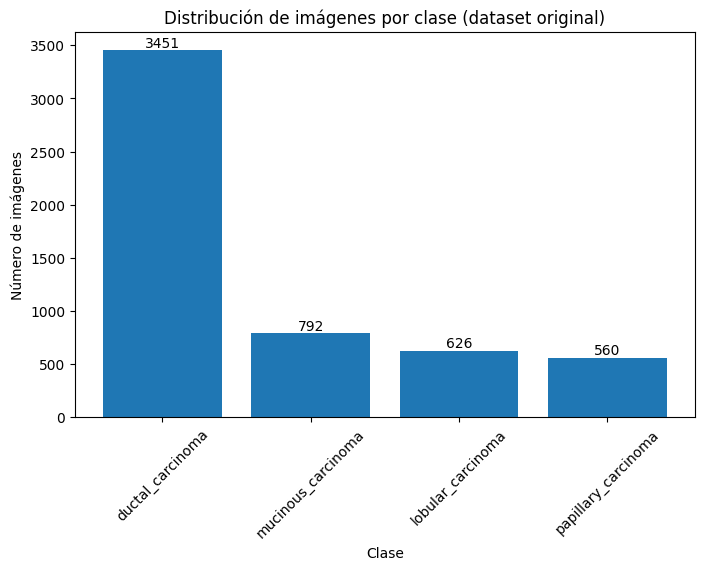

In [ ]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(8,5))
bars = plt.bar(classes, counts)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Distribución de imágenes por clase (dataset original)")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.show()

## Análisis de dimensiones y canales

En esta sección se revisan algunas propiedades básicas de las imágenes del dataset, como su tamaño, su modo de color y el número de canales. Esta comprobación permite tener una visión general del tipo de imágenes con las que se está trabajando y detectar posibles inconsistencias antes de continuar con el entrenamiento del modelo.

En esta celda se recorren todas las carpetas del dataset y se leen las imágenes que tienen una extensión válida. Para cada archivo, se extrae su ancho, su alto, el modo de color y el número de canales, y toda esa información se guarda en una lista que después se convierte en un DataFrame.

 Al final, se muestra cuántas imágenes se han analizado y una vista previa de la tabla generada.

In [ ]:
# extensiones válidas
valid_ext = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

image_info = []

# se recorren las imagenes y se saca la informacion
for class_name in os.listdir(data_dir):

    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):

        for fname in os.listdir(class_path):

            if fname.lower().endswith(valid_ext):

                fpath = os.path.join(class_path, fname)

                try:
                    with Image.open(fpath) as img:

                        width, height = img.size
                        mode = img.mode

                        if mode == 'RGB':
                            channels = 3
                        elif mode == 'RGBA':
                            channels = 4
                        elif mode == 'L':
                            channels = 1
                        else:
                            channels = None

                        image_info.append({
                            'class': class_name,
                            'filename': fname,
                            'width': width,
                            'height': height,
                            'mode': mode,
                            'channels': channels
                        })

                except Exception:
                    image_info.append({
                        'class': class_name,
                        'filename': fname,
                        'width': None,
                        'height': None,
                        'mode': 'ERROR',
                        'channels': None
                    })

# se crea la tabla
df_images = pd.DataFrame(image_info)

print("Número total de imágenes analizadas:", len(df_images))

df_images.head()

Número total de imágenes analizadas: 5429


,class,filename,width,height,mode,channels
0,ductal_carcinoma,SOB_M_DC-14-5694-200-002.png,700,460,RGB,3
1,ductal_carcinoma,SOB_M_DC-14-9461-200-063.png,700,460,RGB,3
2,ductal_carcinoma,SOB_M_DC-14-5695-40-004.png,700,460,RGB,3
3,ductal_carcinoma,SOB_M_DC-14-17901-100-005.png,700,460,RGB,3
4,ductal_carcinoma,SOB_M_DC-14-2523-100-034.png,700,460,RGB,3


En este bloque se agrupan las imágenes según su ancho y su alto para ver cuántos tamaños distintos aparecen en el dataset y cuántas imágenes hay de cada uno.

In [ ]:
size_counts = df_images.groupby(['width', 'height']).size().reset_index(name='count')
size_counts = size_counts.sort_values(['width', 'height'])
print("Número de tamaños distintos:", len(size_counts))
size_counts.head()

Número de tamaños distintos: 2


,width,height,count
0,700,456,74
1,700,460,5355


En esta celda se selecciona una imagen de ejemplo con resolución **700x460** y se muestra por pantalla para comprobar visualmente cómo es una de las dimensiones más frecuentes del dataset.

(np.float64(-0.5), np.float64(699.5), np.float64(459.5), np.float64(-0.5))

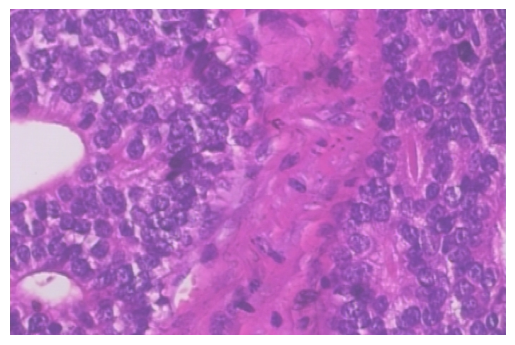

In [ ]:
row = df_images[(df_images['width'] == 700) & (df_images['height'] == 460)].iloc[0]

img_path = f"/content/dataset_malignos/{row['class']}/{row['filename']}"

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')

En esta celda se hace lo mismo con una imagen de tamaño **700x456**, con el fin de comparar visualmente esta pequeña variación de resolución respecto al tamaño principal del conjunto de datos.

(np.float64(-0.5), np.float64(699.5), np.float64(455.5), np.float64(-0.5))

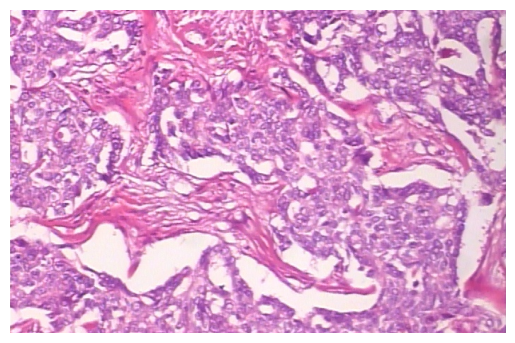

In [ ]:
row = df_images[(df_images['width'] == 700) & (df_images['height'] == 456)].iloc[0]

img_path = f"/content/dataset_malignos/{row['class']}/{row['filename']}"

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')

Este gráfico muestra que el ancho de las imágenes es prácticamente uniforme en todo el dataset, ya que todas se concentran en torno a los **700 píxeles**. Esto indica que no existe variabilidad relevante en esta dimensión y que el conjunto de imágenes mantiene una estructura muy consistente.

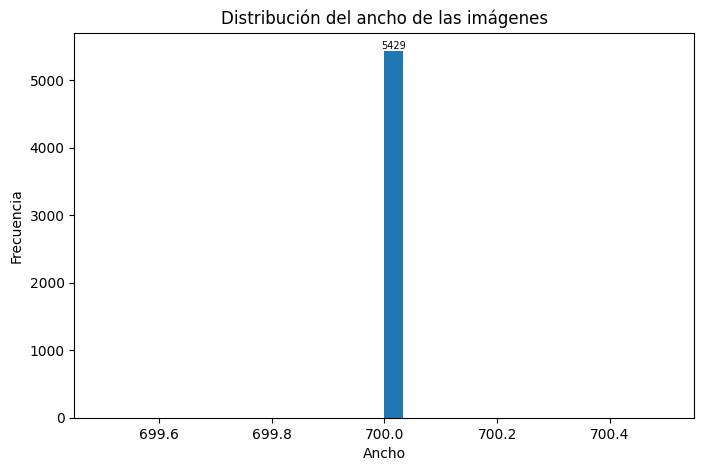

In [ ]:
plt.figure(figsize=(8,5))
counts, edges, patches = plt.hist(df_images['width'].dropna(), bins=30)

for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            str(int(count)),
            ha='center', va='bottom', fontsize=7
        )

plt.title('Distribución del ancho de las imágenes')
plt.xlabel('Ancho')
plt.ylabel('Frecuencia')
plt.show()

En este gráfico puede verse que la altura de las imágenes también es muy homogénea, ya que la gran mayoría tiene una altura de **460 píxeles**. Solo aparece un número muy reducido de imágenes con **456 píxeles**, por lo que esta variación es mínima y no altera la consistencia general del dataset.

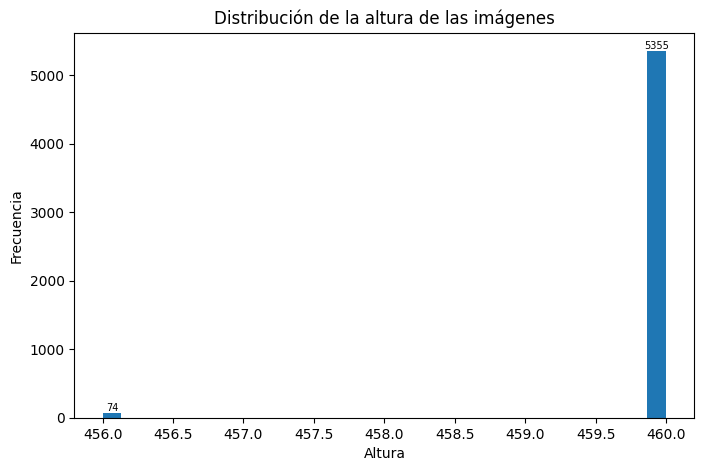

In [ ]:
plt.figure(figsize=(8,5))
counts, edges, patches = plt.hist(df_images['height'].dropna(), bins=30)

for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            str(int(count)),
            ha='center', va='bottom', fontsize=7
        )

plt.title('Distribución de la altura de las imágenes')
plt.xlabel('Altura')
plt.ylabel('Frecuencia')
plt.show()

En esta celda se cuenta cuántas imágenes hay de cada **modo de color**. Esto permite comprobar si todas las imágenes están en el mismo formato o si existen diferencias, por ejemplo entre imágenes en escala de grises, RGB o con canal alfa.

In [ ]:
print(df_images['mode'].value_counts())

mode
RGB    5429
Name: count, dtype: int64


## Comprobación de imágenes corruptas

En este bloque se revisa si alguna imagen no ha podido leerse correctamente durante el análisis anterior. Primero se cuenta cuántos archivos presentan error y, si existiera alguno, también se muestra cómo se distribuyen por clase para localizar más fácilmente dónde está el problema.

Si no aparecen errores, se confirma que el dataset puede utilizarse con normalidad en las siguientes fases del notebook.

In [ ]:
errores = df_images[df_images['mode'] == 'ERROR']
print("Número de imágenes con error:", len(errores))

if len(errores) == 0:
    print("No hay imágenes corruptas en el dataset.")
else:
    errores_por_clase = errores['class'].value_counts()
    plt.figure(figsize=(8, 5))
    bars = plt.bar(errores_por_clase.index, errores_por_clase.values, color='tomato')
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
    plt.title('Imágenes corruptas por clase')
    plt.xlabel('Clase')
    plt.ylabel('Número de imágenes corruptas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Número de imágenes con error: 0
No hay imágenes corruptas en el dataset.


## División en entrenamiento, validación y test

En esta sección se separan las imágenes en tres subconjuntos: **train**, **validation** y **test**. Esta división permite entrenar el modelo con un conjunto de datos, ajustar y supervisar su comportamiento con otro y, finalmente, evaluar su rendimiento sobre imágenes no vistas durante el aprendizaje.

De esta forma, cada subconjunto cumple una función distinta dentro del proceso y ayuda a que la evaluación final del modelo sea más fiable.

In [ ]:
data_dir = '/content/dataset_malignos'
output_base = '/content/dataset_split'

# Crear estructura de carpetas
for split in ['train', 'val', 'test']:
    split_path = os.path.join(output_base, split)
    os.makedirs(split_path, exist_ok=True)

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            os.makedirs(os.path.join(split_path, class_name), exist_ok=True)

# Split por clase
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]

        train_files, temp_files = train_test_split(
            images,
            test_size=0.30,
            random_state=42
        )

        val_files, test_files = train_test_split(
            temp_files,
            test_size=0.50,
            random_state=42
        )

        for f in train_files:
            shutil.copy2(
                os.path.join(class_path, f),
                os.path.join(output_base, 'train', class_name, f)
            )

        for f in val_files:
            shutil.copy2(
                os.path.join(class_path, f),
                os.path.join(output_base, 'val', class_name, f)
            )

        for f in test_files:
            shutil.copy2(
                os.path.join(class_path, f),
                os.path.join(output_base, 'test', class_name, f)
            )

print("Split realizado correctamente")

Split realizado correctamente


### Distribución de las clases en Train

En este bloque se analiza cuántas imágenes de cada clase han quedado dentro del conjunto de **train**. El gráfico permite ver de forma clara que el desbalanceo sigue presente después de la división, ya que **ductal_carcinoma** continúa siendo la clase claramente mayoritaria, mientras que **mucinous_carcinoma**, **lobular_carcinoma** y **papillary_carcinoma** quedan bastante por debajo.

Esta diferencia es importante porque puede influir en el aprendizaje del modelo, haciendo que tienda a reconocer mejor la clase con más ejemplos si no se aplican medidas para compensarlo.

In [ ]:
train_dir = '/content/dataset_split/train'

train_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
        train_counts[class_name] = len(images)

print("Conteo en train:")
print(train_counts)

Conteo en train:
{'ductal_carcinoma': 2415, 'mucinous_carcinoma': 554, 'lobular_carcinoma': 438, 'papillary_carcinoma': 392}


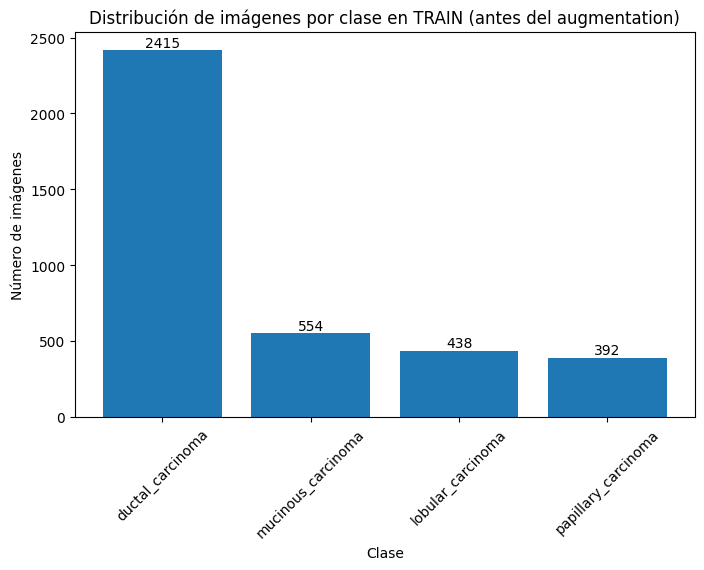

In [ ]:
classes = list(train_counts.keys())
counts = list(train_counts.values())

plt.figure(figsize=(8,5))
bars = plt.bar(classes, counts)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Distribución de imágenes por clase en TRAIN (antes del augmentation)")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.show()

### Distribución de clases en el conjunto de validación

En esta parte se representa la distribución de imágenes por clase dentro del conjunto de **validation**. Puede verse que se mantiene el mismo patrón que en el conjunto de entrenamiento: **ductal_carcinoma** sigue siendo la clase más numerosa, mientras que las demás clases cuentan con una representación bastante menor.

Esto es importante porque el conjunto de validación debe reflejar la distribución real del problema para que las métricas obtenidas durante el entrenamiento sean representativas.

In [ ]:
val_dir = '/content/dataset_split/val'

val_counts = {}

for class_name in os.listdir(val_dir):
    class_path = os.path.join(val_dir, class_name)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
        val_counts[class_name] = len(images)

print("Conteo en val:")
print(val_counts)

Conteo en val:
{'ductal_carcinoma': 518, 'mucinous_carcinoma': 119, 'lobular_carcinoma': 94, 'papillary_carcinoma': 84}


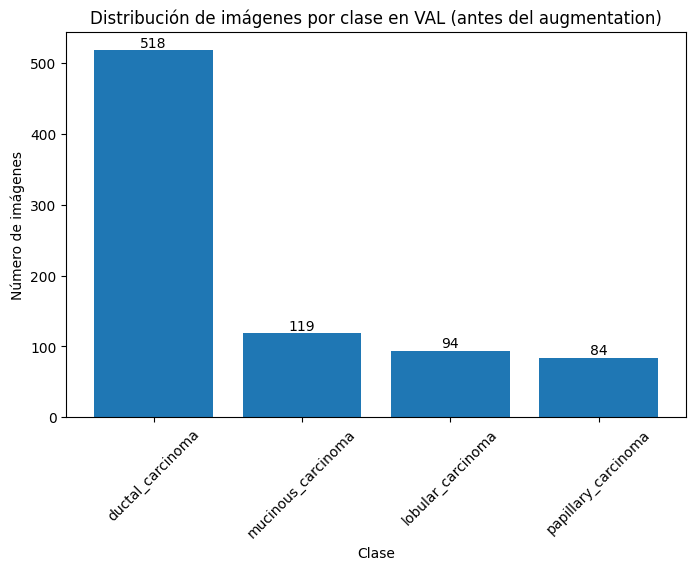

In [ ]:
classes = list(val_counts.keys())
counts = list(val_counts.values())

plt.figure(figsize=(8,5))
bars = plt.bar(classes, counts)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Distribución de imágenes por clase en VAL (antes del augmentation)")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.show()

### Distribución de clases en el conjunto de test

En este bloque se muestra cómo han quedado repartidas las imágenes por clase dentro del conjunto de **test**. La distribución mantiene el mismo patrón observado en entrenamiento y validación, con **ductal_carcinoma** como clase mayoritaria y el resto de subtipos con una representación bastante menor.

Esto permite que la evaluación final del modelo se realice sobre un conjunto independiente que conserva la misma estructura general del problema.

In [ ]:
test_dir = '/content/dataset_split/test'

test_counts = {}

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
        test_counts[class_name] = len(images)

print("Conteo en test:")
print(test_counts)

Conteo en test:
{'ductal_carcinoma': 518, 'mucinous_carcinoma': 119, 'lobular_carcinoma': 94, 'papillary_carcinoma': 84}


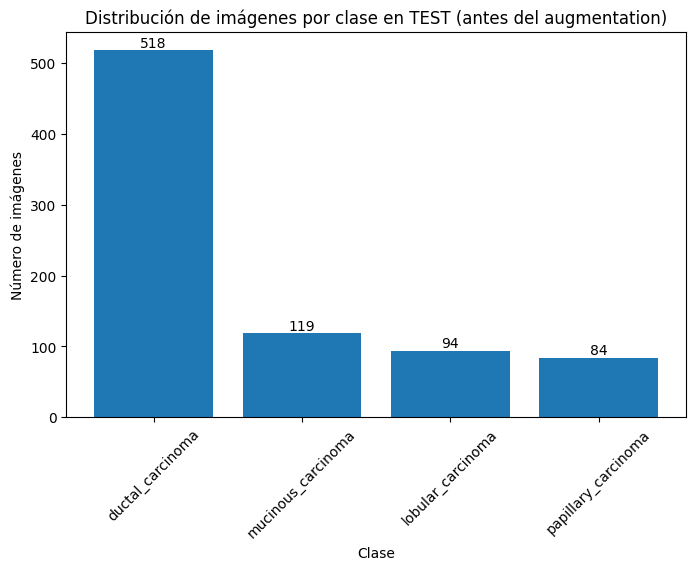

In [ ]:
classes = list(test_counts.keys())
counts = list(test_counts.values())

plt.figure(figsize=(8,5))
bars = plt.bar(classes, counts)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Distribución de imágenes por clase en TEST (antes del augmentation)")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.show()

## Data Augmentation en Train

Después de aplicar **data augmentation**, la distribución de clases en **train** queda mucho más equilibrada. Aunque **ductal_carcinoma** sigue siendo la clase con más imágenes, la diferencia con respecto a **mucinous_carcinoma**, **lobular_carcinoma** y **papillary_carcinoma** se reduce de forma notable.

Esto permite trabajar con un conjunto de entrenamiento más balanceado, aumentando la presencia de las clases minoritarias sin modificar los conjuntos de validación y test.

In [ ]:
target_count = 2000

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True,
    brightness_range=(0.9, 1.1),   # fotométrica suave: brillo
    channel_shift_range=10.0,      # fotométrica suave: leve cambio de color
    fill_mode='nearest'
)

print("Objetivo por clase en train:", target_count)

Objetivo por clase en train: 2000


In [ ]:
train_dir = '/content/dataset_split/train'

for class_name, current_count in train_counts.items():
    class_path = os.path.join(train_dir, class_name)

    if current_count < target_count:
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
        ]

        n_to_generate = target_count - current_count
        generated = 0

        print(f"\nClase: {class_name}")
        print(f"Imágenes originales en train: {current_count}")
        print(f"Imágenes a generar: {n_to_generate}")

        while generated < n_to_generate:
            img_name = random.choice(image_files)
            img_path = os.path.join(class_path, img_name)

            img = load_img(img_path, target_size=(224, 224))
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            aug_iter = datagen.flow(
                x,
                batch_size=1,
                save_to_dir=class_path,
                save_prefix='aug',
                save_format='jpg'
            )

            next(aug_iter)
            generated += 1

        print(f"Generadas: {generated}")

    else:
        print(f"\nClase {class_name}: no necesita augmentation")


Clase ductal_carcinoma: no necesita augmentation

Clase: mucinous_carcinoma
Imágenes originales en train: 554
Imágenes a generar: 1446
Generadas: 1446

Clase: lobular_carcinoma
Imágenes originales en train: 438
Imágenes a generar: 1562
Generadas: 1562

Clase: papillary_carcinoma
Imágenes originales en train: 392
Imágenes a generar: 1608
Generadas: 1608


In [ ]:
final_train_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
        ]
        final_train_counts[class_name] = len(images)

print("Conteo final en train:")
print(final_train_counts)

Conteo final en train:
{'ductal_carcinoma': 2415, 'mucinous_carcinoma': 1900, 'lobular_carcinoma': 1869, 'papillary_carcinoma': 1884}


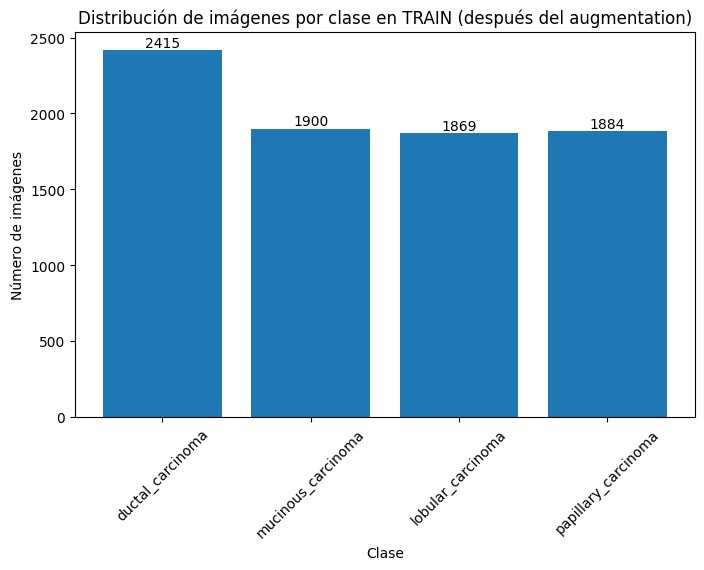

In [ ]:
classes = list(final_train_counts.keys())
counts = list(final_train_counts.values())

plt.figure(figsize=(8,5))
bars = plt.bar(classes, counts)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        int(yval),
        ha='center',
        va='bottom'
    )

plt.title("Distribución de imágenes por clase en TRAIN (después del augmentation)")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.show()

### Comparación del dataset con y sin data augmentation

En esta comparación puede verse de forma clara el efecto del **data augmentation** sobre el conjunto de entrenamiento. Antes de aplicarlo, la clase **ductal_carcinoma** estaba muy por encima del resto, mientras que después las clases minoritarias aumentan considerablemente y la distribución queda mucho más equilibrada.

La diferencia no desaparece por completo, pero sí se reduce lo suficiente como para que el modelo entrene con una representación mucho más parecida entre clases.


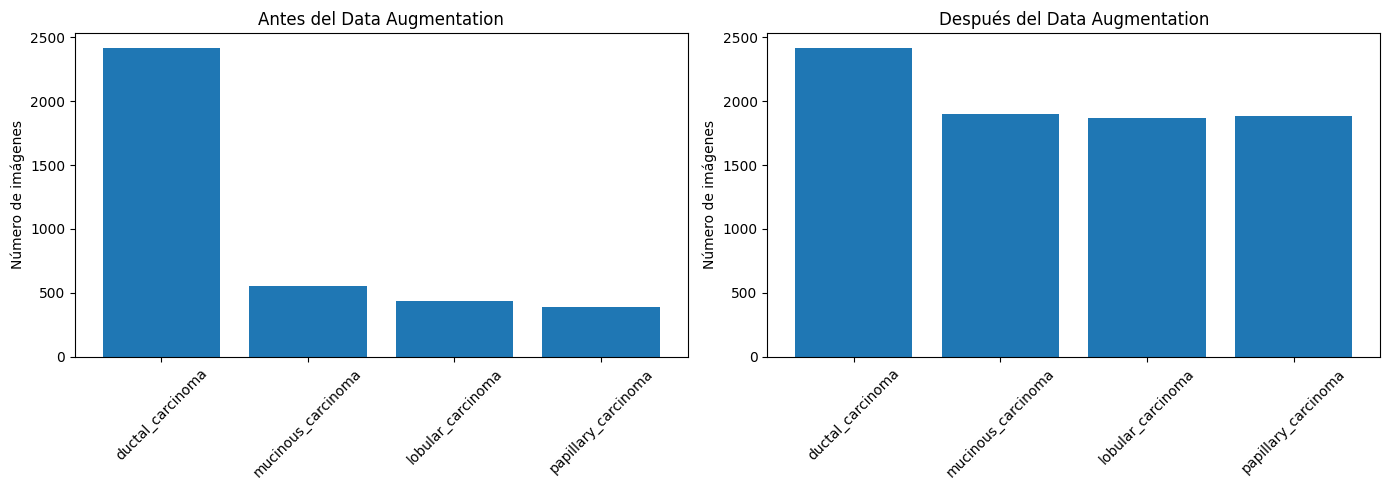

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].bar(train_counts.keys(), train_counts.values())
axes[0].set_title("Antes del Data Augmentation")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Número de imágenes")

axes[1].bar(final_train_counts.keys(), final_train_counts.values())
axes[1].set_title("Después del Data Augmentation")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel("Número de imágenes")

plt.tight_layout()
plt.show()

## Generadores

En esta parte se configuran los generadores que se utilizarán para cargar las imágenes por lotes durante el entrenamiento, la validación y la prueba. Todas las imágenes se redimensionan a **224x224 píxeles** y se normalizan dividiendo sus valores entre 255, de forma que queden en el rango **[0, 1]**.

Además, se crean tres generadores distintos, uno para cada subconjunto del dataset. En el caso del conjunto de **test**, se desactiva el mezclado aleatorio de imágenes para que el orden de las predicciones coincida exactamente con el de las etiquetas reales al calcular las métricas.

In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# generador de train
train_generator = train_datagen.flow_from_directory(
    '/content/dataset_split/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# generador de validacion
val_generator = val_test_datagen.flow_from_directory(
    '/content/dataset_split/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# generador de test
test_generator = val_test_datagen.flow_from_directory(
    '/content/dataset_split/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 8068 images belonging to 4 classes.
Found 815 images belonging to 4 classes.
Found 815 images belonging to 4 classes.


In [ ]:
# se muestran los indices de cada una de las clases
print(train_generator.class_indices)

{'ductal_carcinoma': 0, 'lobular_carcinoma': 1, 'mucinous_carcinoma': 2, 'papillary_carcinoma': 3}
